### Introduction to Regression with Neural Networks in TensorFlow

In [2]:
# Import TensorFlow
import tensorflow as tf 
print(tf.__version__)


2.15.0


### Creating data to view and fit

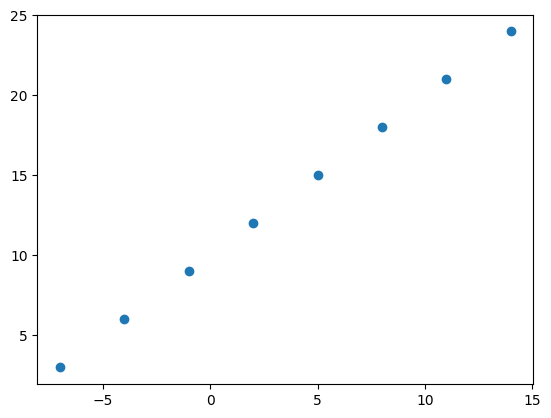

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y)

### Input and Output shapes

In [4]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [5]:
# Turn our Numpy arrays into tensors  with dtype float32
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [6]:
input_shape = X[0].shape 
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

### Steps in modelling with TensorFlow

In [7]:
# Set random seed
tf.random.set_seed(29)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae, # Mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)      


Epoch 1/5


1/1 [==============================] - 1s 831ms/step - loss: 14.4410 - mae: 14.4410
Epoch 2/5
1/1 [==============================] - 0s 7ms/step - loss: 14.3085 - mae: 14.3085
Epoch 3/5
1/1 [==============================] - 0s 7ms/step - loss: 14.1760 - mae: 14.1760
Epoch 4/5
1/1 [==============================] - 0s 6ms/step - loss: 14.0435 - mae: 14.0435
Epoch 5/5
1/1 [==============================] - 0s 7ms/step - loss: 13.9110 - mae: 13.9110


In [8]:
# Try and make a prediction using our model
model.predict([17.0])

1/1 [==============================] - 0s 111ms/step


array([[-1.5454823]], dtype=float32)

## Improving our model

In [10]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 341ms/step - loss: 14.2759 - mae: 14.2759
Epoch 2/100
1/1 [==============================] - 0s 6ms/step - loss: 14.1434 - mae: 14.1434
Epoch 3/100
1/1 [==============================] - 0s 6ms/step - loss: 14.0109 - mae: 14.0109
Epoch 4/100
1/1 [==============================] - 0s 7ms/step - loss: 13.8784 - mae: 13.8784
Epoch 5/100
1/1 [==============================] - 0s 8ms/step - loss: 13.7459 - mae: 13.7459
Epoch 6/100
1/1 [==============================] - 0s 6ms/step - loss: 13.6134 - mae: 13.6134
Epoch 7/100
1/1 [==============================] - 0s 7ms/step - loss: 13.4809 - mae: 13.4809
Epoch 8/100
1/1 [==============================] - 0s 6ms/step - loss: 13.3484 - mae: 13.3484
Epoch 9/100
1/1 [==============================] - 0s 6ms/step - loss: 13.2159 - mae: 13.2159
Epoch 10/100
1/1 [==============================] - 0s 7ms/step - loss: 13.0834 - mae: 13.0834
Epoch 11/100
1/1 [==============================] - 0s 6m

In [11]:
# Let's see if our model's prediction has improved
model.predict([17.0])

1/1 [==============================] - 0s 84ms/step


array([[29.843725]], dtype=float32)

In [34]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
   tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 391ms/step - loss: 18.2764 - mae: 18.2764
Epoch 2/100
1/1 [==============================] - 0s 7ms/step - loss: 18.2704 - mae: 18.2704
Epoch 3/100
1/1 [==============================] - 0s 8ms/step - loss: 18.2644 - mae: 18.2644
Epoch 4/100
1/1 [==============================] - 0s 15ms/step - loss: 18.2584 - mae: 18.2584
Epoch 5/100
1/1 [==============================] - 0s 10ms/step - loss: 18.2524 - mae: 18.2524
Epoch 6/100
1/1 [==============================] - 0s 12ms/step - loss: 18.2464 - mae: 18.2464
Epoch 7/100
1/1 [==============================] - 0s 8ms/step - loss: 18.2404 - mae: 18.2404
Epoch 8/100
1/1 [==============================] - 0s 9ms/step - loss: 18.2344 - mae: 18.2344
Epoch 9/100
1/1 [==============================] - 0s 5ms/step - loss: 18.2284 - mae: 18.2284
Epoch 10/100
1/1 [==============================] - 0s 6ms/step - loss: 18.2224 - mae: 18.2224
Epoch 11/100
1/1 [==============================] - 0s

In [33]:
model.predict([18.0])

1/1 [==============================] - 0s 71ms/step


array([[6.867419]], dtype=float32)

In [42]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 1s 570ms/step - loss: 14.5598 - mae: 14.5598
Epoch 2/100
1/1 [==============================] - 0s 8ms/step - loss: 13.8697 - mae: 13.8697
Epoch 3/100
1/1 [==============================] - 0s 7ms/step - loss: 13.1782 - mae: 13.1782
Epoch 4/100
1/1 [==============================] - 0s 6ms/step - loss: 12.4832 - mae: 12.4832
Epoch 5/100
1/1 [==============================] - 0s 8ms/step - loss: 11.7830 - mae: 11.7830
Epoch 6/100
1/1 [==============================] - 0s 6ms/step - loss: 11.0756 - mae: 11.0756
Epoch 7/100
1/1 [==============================] - 0s 8ms/step - loss: 10.3589 - mae: 10.3589
Epoch 8/100
1/1 [==============================] - 0s 8ms/step - loss: 9.6306 - mae: 9.6306
Epoch 9/100
1/1 [==============================] - 0s 6ms/step - loss: 8.8888 - mae: 8.8888
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 8.1311 - mae: 8.1311
Epoch 11/100
1/1 [==============================] - 0s 7ms/step

In [43]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 87ms/step


array([[27.299656]], dtype=float32)

### Evaluating a model 

In practice, a typical workflow you'll go through when building neural networks is:

```
Built a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it.....
```

In [57]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X


<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [58]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

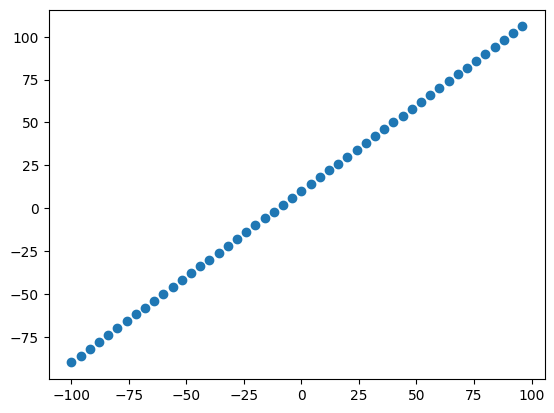

In [59]:
# Visualize the data 
import matplotlib.pyplot as plt

plt.scatter(X, y)

### The 3 sets...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data available.

In [60]:
# Check the length of how many samples we have
len(X)

50

In [65]:
# Split the data into train and test sets
X_train = X[:40] # First 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(X_test), len(y_test)

(40, 10, 10, 10)

### Visualizing the data
Now we've got our data in training and test sets...let's visualize it again!

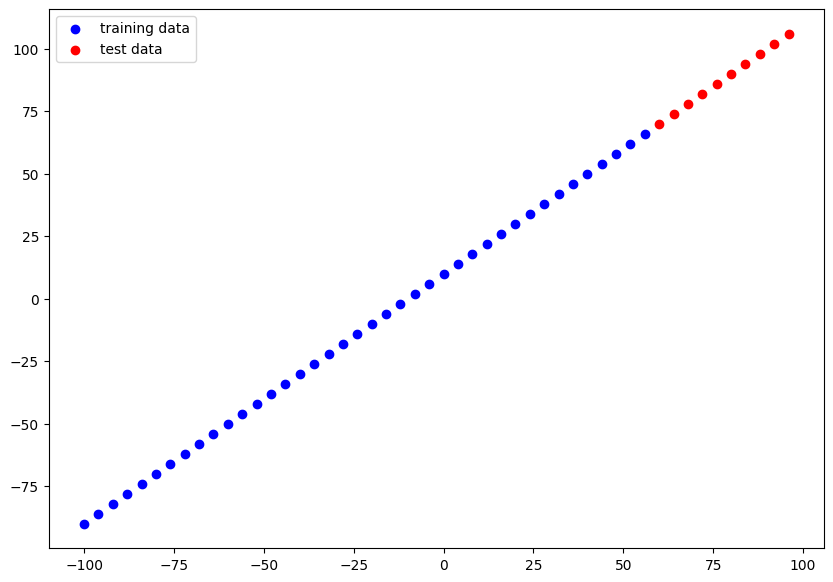

In [66]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="training data")

# Plot test data in red
plt.scatter(X_test, y_test, c="r", label="test data")

# Legend
plt.legend();

In [75]:
# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [76]:
model.summary()

Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_33 (Dense)            (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [77]:
# Let's fit the model with training data
model.fit(tf.expand_dims(X, -1), y, epochs=100, verbose=2)

Epoch 1/100
2/2 - 0s - loss: 32.2234 - mae: 32.2234 - 310ms/epoch - 155ms/step
Epoch 2/100
2/2 - 0s - loss: 11.2390 - mae: 11.2390 - 5ms/epoch - 3ms/step
Epoch 3/100
2/2 - 0s - loss: 11.3826 - mae: 11.3826 - 5ms/epoch - 3ms/step
Epoch 4/100
2/2 - 0s - loss: 12.8849 - mae: 12.8849 - 5ms/epoch - 3ms/step
Epoch 5/100
2/2 - 0s - loss: 9.6936 - mae: 9.6936 - 5ms/epoch - 2ms/step
Epoch 6/100
2/2 - 0s - loss: 11.1842 - mae: 11.1842 - 4ms/epoch - 2ms/step
Epoch 7/100
2/2 - 0s - loss: 9.9742 - mae: 9.9742 - 4ms/epoch - 2ms/step
Epoch 8/100
2/2 - 0s - loss: 10.2983 - mae: 10.2983 - 4ms/epoch - 2ms/step
Epoch 9/100
2/2 - 0s - loss: 10.8962 - mae: 10.8962 - 4ms/epoch - 2ms/step
Epoch 10/100
2/2 - 0s - loss: 9.9557 - mae: 9.9557 - 4ms/epoch - 2ms/step
Epoch 11/100
2/2 - 0s - loss: 10.1057 - mae: 10.1057 - 5ms/epoch - 2ms/step
Epoch 12/100
2/2 - 0s - loss: 10.1131 - mae: 10.1131 - 5ms/epoch - 2ms/step
Epoch 13/100
2/2 - 0s - loss: 9.7875 - mae: 9.7875 - 5ms/epoch - 3ms/step
Epoch 14/100
2/2 - 0s - l